In [2]:
import anndata as ad
import pandas as pd
import scanpy as sc
from pathlib import Path
import os
import sklearn
import scipy
import numpy as np
import sceleto2 as scl
import pickle
import glob
import os
import scrublet as scr
import matplotlib.pyplot as plt


sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=100, dpi_save=300, figsize=(5,5))
sc.settings.figdir = "./figures"
sc.settings.autosave = False
random_seed = 0

from datetime import date
TODAY = date.today()
print(TODAY)

/home/lsj1022/anaconda3/envs/scenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-09-16


# Figures 

In [2]:
ayhan = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/ayhan/ayhan_qc.h5ad")
ayhan

AnnData object with n_obs × n_vars = 130344 × 17180
    obs: 'temp_sample', 'study_id', 'dataset_id', 'species', 'disease_status', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'fcd_subtype', 'mtoropathy_status', 'driver_mutation_status', 'driver_gene', 'driver_variant', 'mutation_scope', 'brain_region', 'lesion_position', 'control_type', 'sample_source', 'tissue_state', 'cell_or_nucleus', 'platform', 'raw_counts_available', 'cell_metadata_available', 'genetic_metadata_available', 'main_analysis_eligible', 'exclusion_reason', 'processed_file_format', 'geo_downloadable', 'source_url', 'sample_id', 'GSM', 'donor_id', 'donor_id_global', 'brain_region_raw', 'age_years', 'sex', 'epilepsy_duration_years', 'chemistry', 'n_cells_raw', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_coun

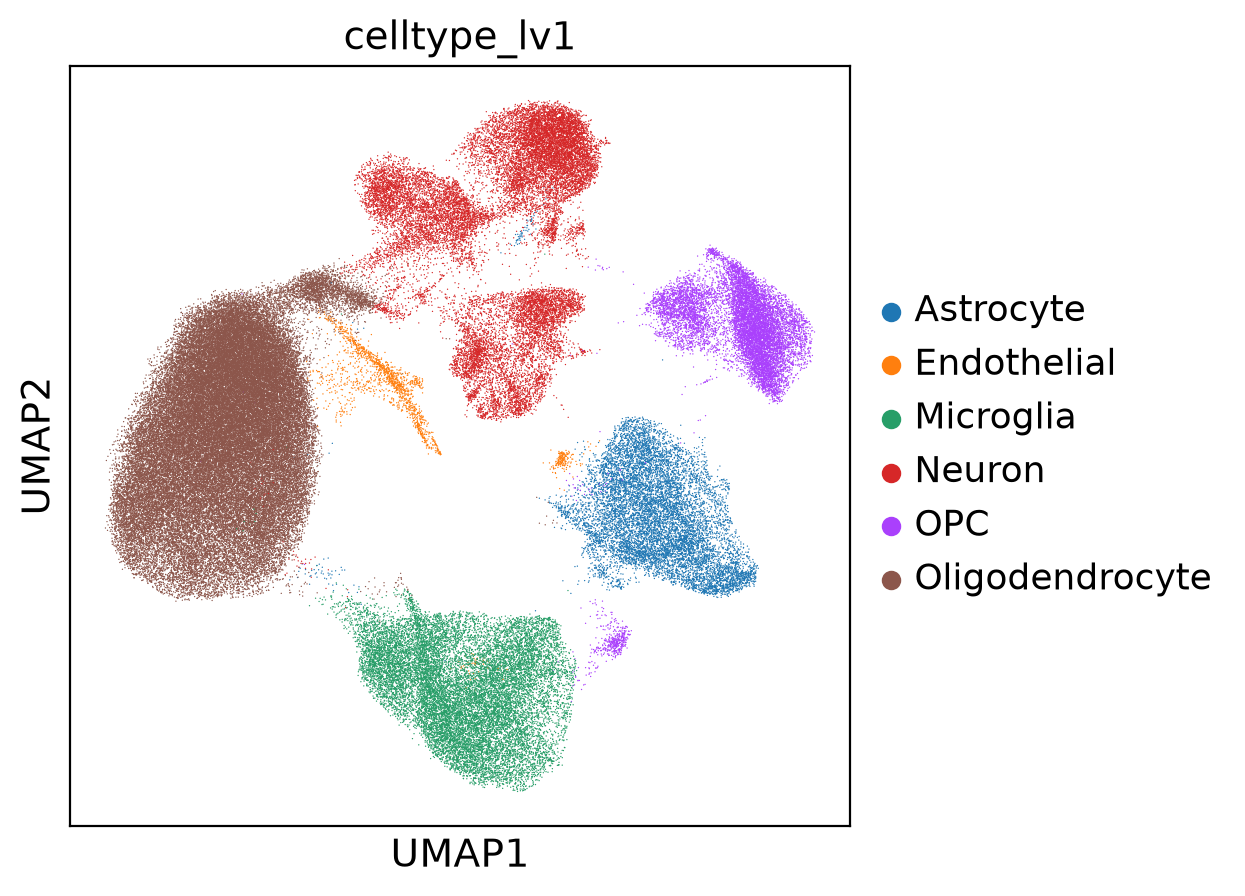

In [3]:
sc.pl.umap(ayhan, color='celltype_lv1')

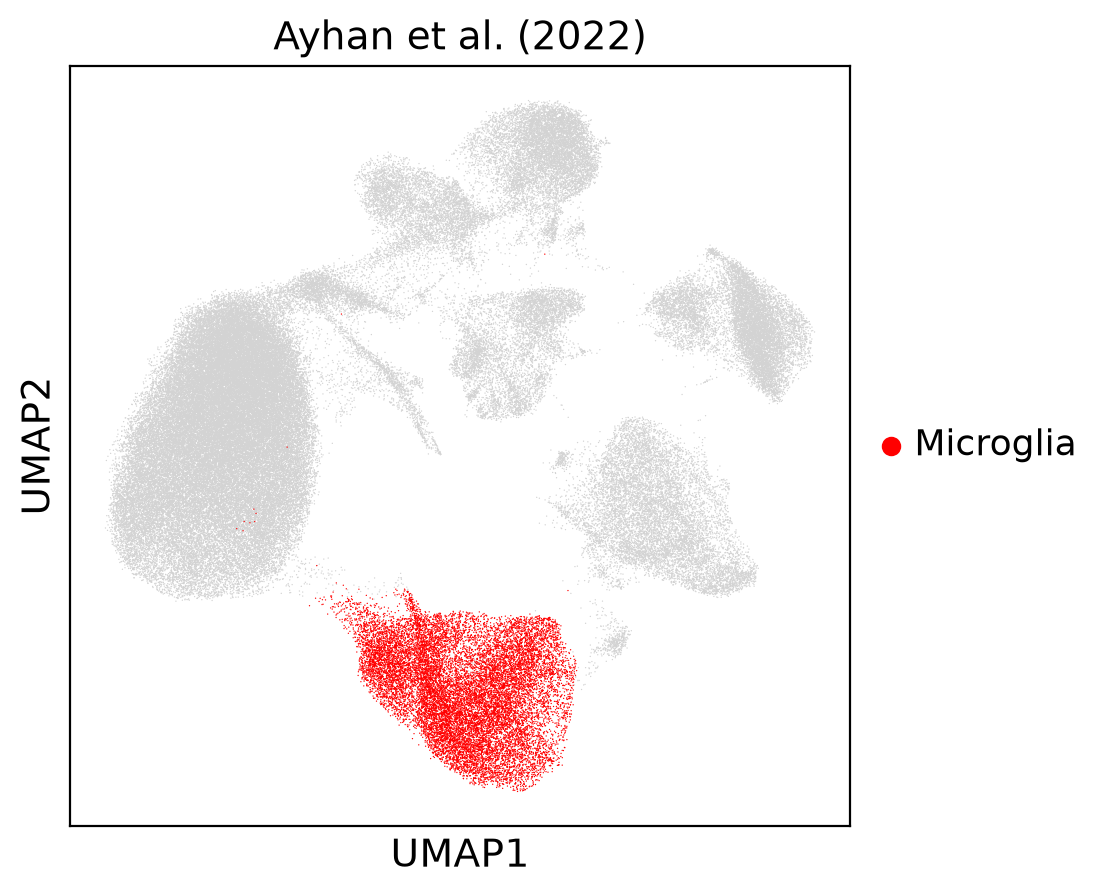

In [12]:
ayhan.obs["Microglia"] = (
    ayhan.obs["celltype_lv1"]
    .where(ayhan.obs["celltype_lv1"].eq("Microglia"))
    .cat.remove_unused_categories()
)

sc.pl.umap(
    ayhan,
    color="Microglia",
    palette={"Microglia": "red"},
    na_color="lightgrey",
    na_in_legend=False,
    title="Ayhan et al. (2022)",
)

In [13]:
galvao = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/galvao/galvao_qc.h5ad")
galvao

AnnData object with n_obs × n_vars = 91862 × 36601
    obs: 'source_cell_id', 'study', 'donor_id', 'sample_id', 'diagnosis', 'pathology', 'fcd_subtype', 'control_status', 'mutation_status', 'brain_region', 'assay', 'platform', 'source_accession', 'source_sample_id', 'source_file', 'paired_atac_accession', 'source_file_sample_id', 'fcd_type', 'geo_accession', 'geo_source_name', 'geo_tissue', 'geo_donor', 'geo_disease', 'geo_library_type', 'geo_Sex', 'geo_age_at_surgery', 'geo_age_at_onset', 'geo_duration', 'geo_lobe', 'geo_lateralization', 'geo_histological_assessment', 'geo_surgery_reason', 'geo_seq_batch', 'geo_platform_id', 'cellxgene_mapped_reference_annotation', 'cellxgene_donor_id', 'cellxgene_self_reported_ethnicity_ontology_term_id', 'cellxgene_donor_living_at_sample_collection', 'cellxgene_sample_uuid', 'cellxgene_sample_preservation_method', 'cellxgene_tissue_ontology_term_id', 'cellxgene_development_stage_ontology_term_id', 'cellxgene_sample_derivation_process', 'cellxgene_ti

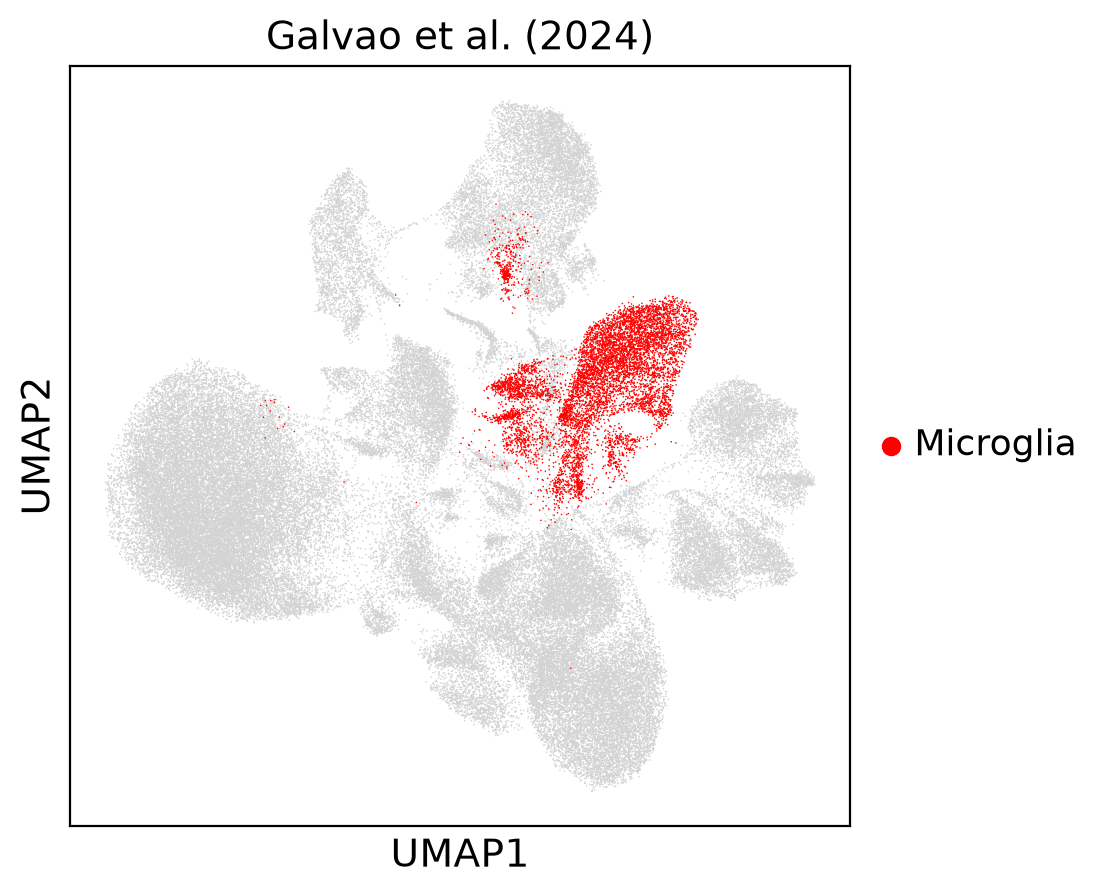

In [20]:
galvao.obs["Microglia"] = (
    galvao.obs["celltype_lv1"]
    .where(galvao.obs["celltype_lv1"].eq("Microglia"))
    .cat.remove_unused_categories()
)

sc.pl.umap(
    galvao,
    color="Microglia",
    palette={"Microglia": "red"},
    na_color="lightgrey",
    na_in_legend=False,
    title="Galvao et al. (2024)",
)

In [15]:
liu = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/liu/liu_qc.h5ad")

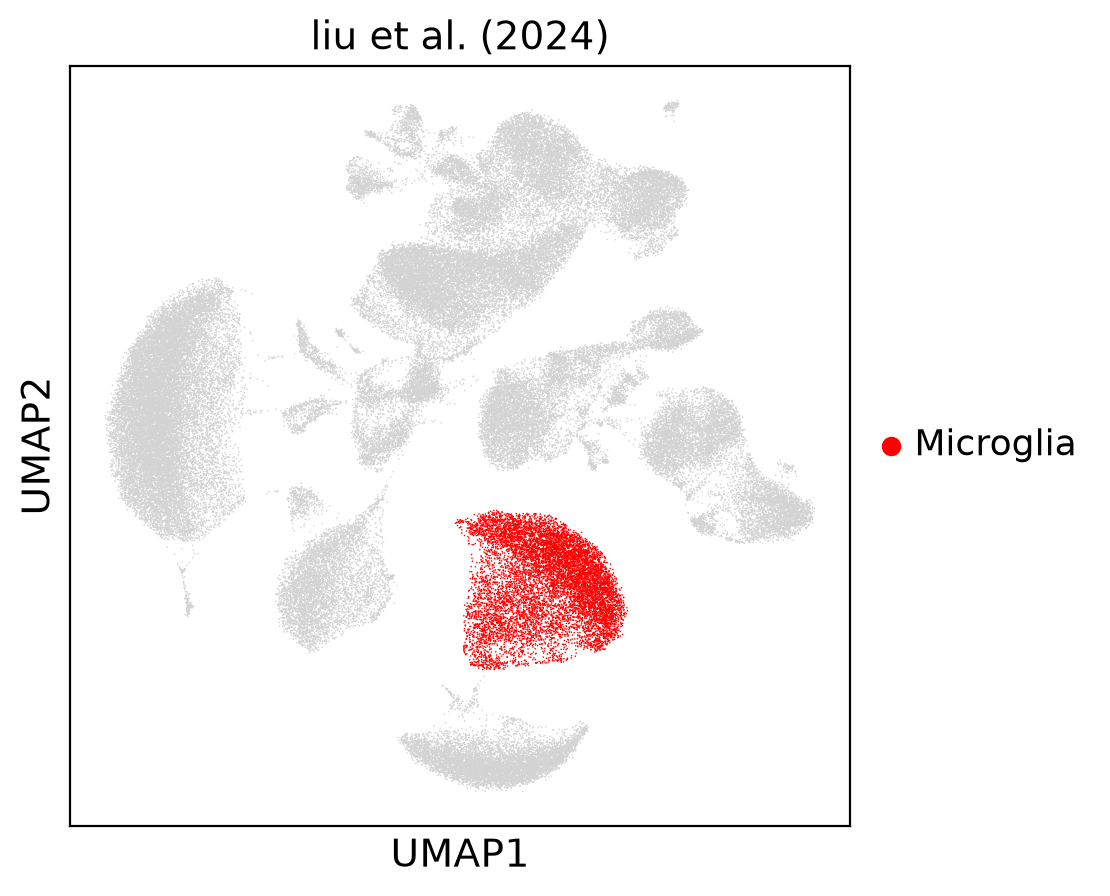

In [17]:
liu.obs["Microglia"] = (
    liu.obs["celltype_lv1"]
    .where(liu.obs["celltype_lv1"].eq("Microglia"))
    .cat.remove_unused_categories()
)

sc.pl.umap(
    liu,
    color="Microglia",
    palette={"Microglia": "red"},
    na_color="lightgrey",
    na_in_legend=False,
    title="liu et al. (2024)",
)

In [24]:
pappalardo_total = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/pappalardo_total/pappalardo_total_qc.h5ad")

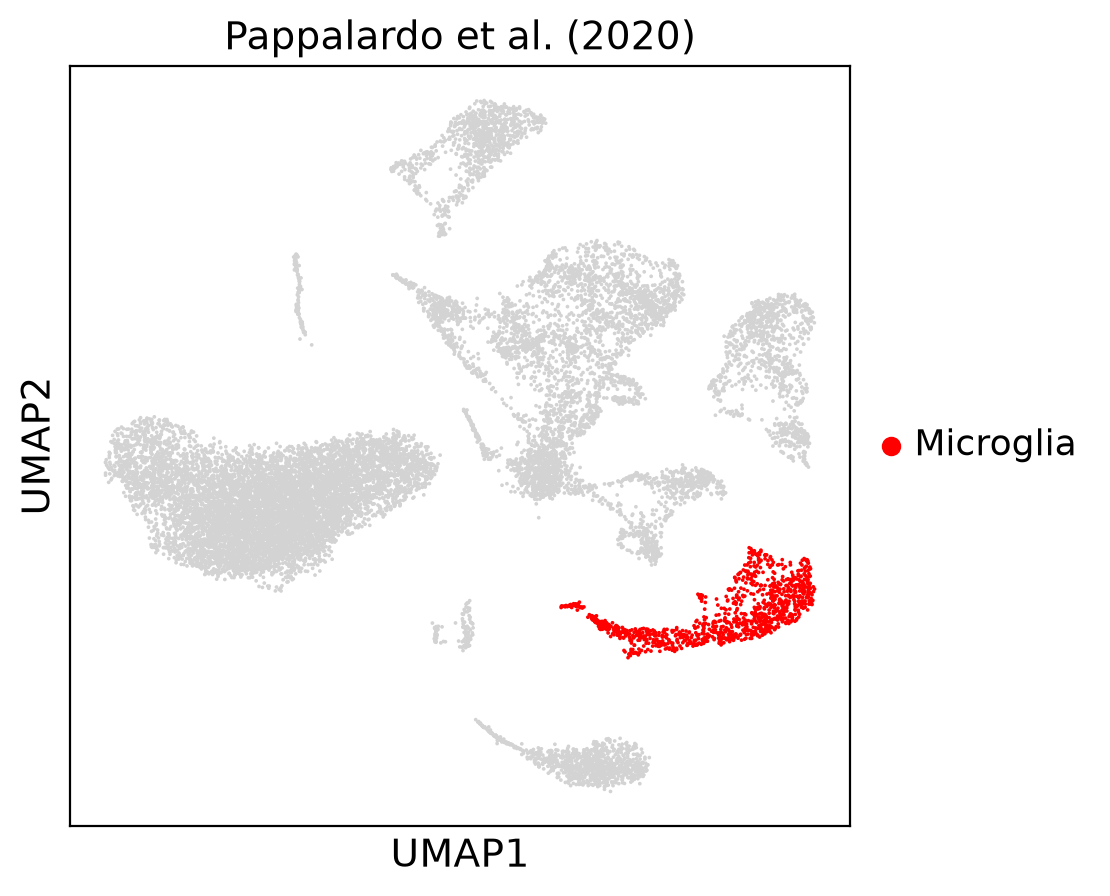

In [25]:
pappalardo_total.obs["Microglia"] = (
    pappalardo_total.obs["celltype_lv1"]
    .where(pappalardo_total.obs["celltype_lv1"].eq("Microglia"))
    .cat.remove_unused_categories()
)

sc.pl.umap(
    pappalardo_total,
    color="Microglia",
    palette={"Microglia": "red"},
    na_color="lightgrey",
    na_in_legend=False,
    title="Pappalardo et al. (2020)",
)

In [26]:
thrupp = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/thrupp/thrupp_qc.h5ad")

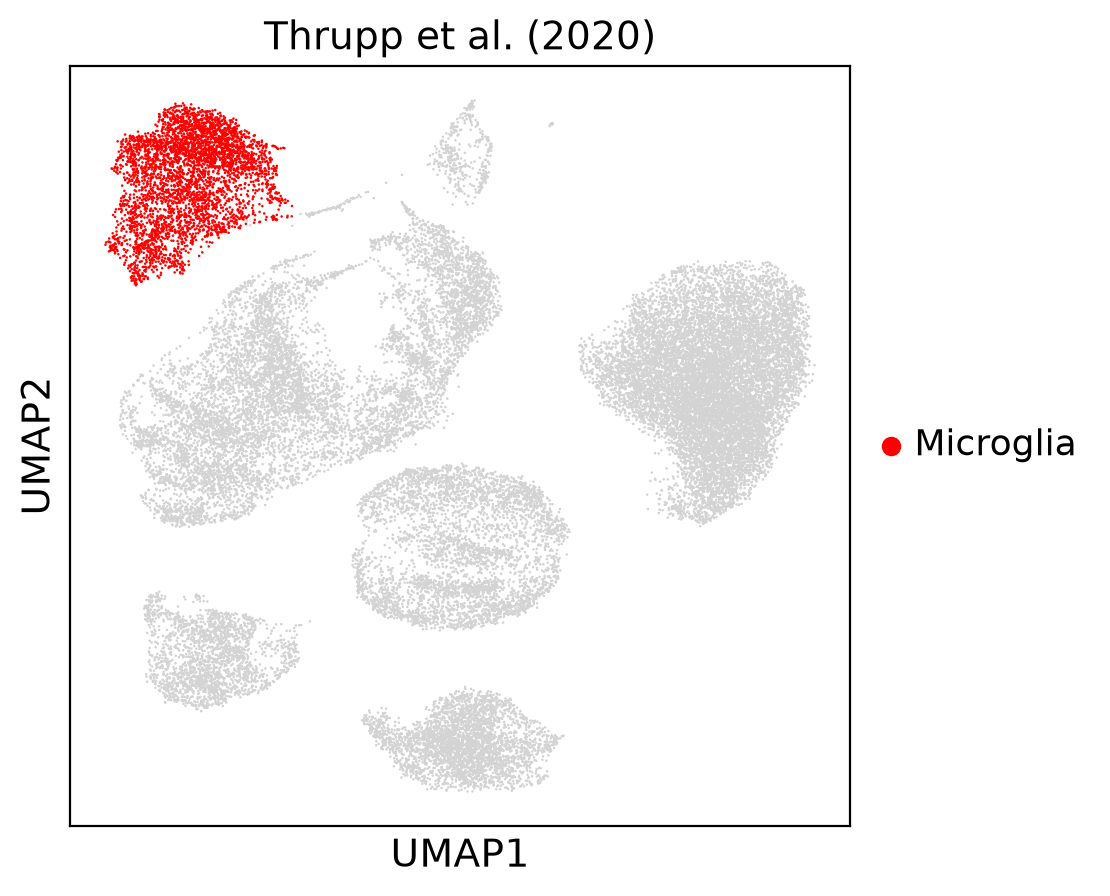

In [27]:
thrupp.obs["Microglia"] = (
    thrupp.obs["celltype_lv1"]
    .where(thrupp.obs["celltype_lv1"].eq("Microglia"))
    .cat.remove_unused_categories()
)

sc.pl.umap(
    thrupp,
    color="Microglia",
    palette={"Microglia": "red"},
    na_color="lightgrey",
    na_in_legend=False,
    title="Thrupp et al. (2020)",
)

# Fig4 cross validation

## Load data

In [3]:
ndata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/integrated/snRNAseq_microglia_cnmfr3_k9.h5ad")
cdata = sc.read_h5ad("/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/processed/kumar/kumar_nmfr2_k7.h5ad")
print(ndata, cdata)

AnnData object with n_obs × n_vars = 30026 × 14642
    obs: 'brain_region', 'platform', 'sample_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'doublet_scores', 'predicted_doublets', 'celltype_lv1', 'study', 'gsm', 'tissue_id', 'donor_id_global', 'brain_region_source', 'tissue_compartment', 'lesion_relation', 'hemisphere', 'diagnosis_raw', 'diagnosis_harmonized', 'fcd_class', 'mtoropathy_status', 'age_years', 'sex', 'epilepsy_duration_years', 'tissue_state', 'scVI_leiden05', 'GEP1', 'GEP2', 'GEP3', 'GEP4', 'GEP5', 'GEP6', 'GEP7', 'GEP8', 'GEP9', 'GEP3_bin', 'GEP3_decile', 'myeloid_identity'
    var: 'mt', '

In [4]:
c_spectra = pd.read_csv(
    '/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/scRNA_microglia_run_2_filtered/scRNA_microglia/scRNA_microglia.gene_spectra_score.k_7.dt_0_01.txt',
    sep='\t',
    index_col=0
)
c_spectra.head()

,ABCB1,ABHD17C,ABHD5,ABL2,ABLIM1,AC000036.4,AC002456.2,AC002511.3,AC003092.1,AC003102.3,...,ZNF676,ZNF703,ZNF711,ZNF812,ZNF844,ZNF860,ZNRD1,ZSWIM2,ZYG11A,hsa-mir-7515
1,-0.000021,-0.000043,0.000255,-0.000735,-0.000007,-0.000010,-0.000023,5.692485e-07,-0.000022,-0.000007,...,0.000018,0.000166,0.000228,0.000371,0.000736,1.185905e-05,0.000214,0.000003,0.000016,-0.000011
2,-0.000039,-0.000057,-0.000040,0.000235,-0.000035,0.000009,-0.000090,2.761816e-05,-0.000017,-0.000067,...,-0.000012,-0.000240,-0.000149,-0.000528,-0.000563,-4.085493e-06,-0.000338,-0.000010,-0.000002,-0.000023
3,-0.000077,0.000022,-0.000347,-0.000440,0.000008,0.000008,-0.000216,-2.711326e-05,-0.000037,0.000107,...,-0.000009,-0.000014,-0.000003,-0.000091,-0.000350,-8.945315e-06,0.000239,-0.000002,-0.000022,0.000064
4,0.000031,-0.000046,-0.000199,0.001331,-0.000060,-0.000010,0.000094,8.437797e-06,0.000009,-0.000050,...,-0.000017,0.000192,-0.000275,-0.000189,-0.000243,-7.988715e-06,-0.000264,-0.000008,-0.000030,-0.000008
5,0.000334,0.000162,-0.000099,-0.000319,0.000168,-0.000004,0.000552,-1.283487e-05,-0.000053,-0.000016,...,-0.000006,-0.000274,-0.000147,0.000037,-0.000153,3.269140e-08,-0.000007,-0.000003,-0.000009,-0.000005


In [5]:
c_spectra_tpm = pd.read_csv(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/scRNA_microglia_run_2_filtered/scRNA_microglia/scRNA_microglia.gene_spectra_tpm.k_7.dt_0_01.txt",
    sep='\t',
    index_col=0
)
c_spectra_tpm.head()

,ABCB1,ABHD17C,ABHD5,ABL2,ABLIM1,AC000036.4,AC002456.2,AC002511.3,AC003092.1,AC003102.3,...,ZNF676,ZNF703,ZNF711,ZNF812,ZNF844,ZNF860,ZNRD1,ZSWIM2,ZYG11A,hsa-mir-7515
1,0.149709,1.425115,437.740330,0.00000,2.213685,0.000000,0.000000,0.007291,0.0,3.239849,...,0.292478,414.90960,493.13773,414.787140,615.697630,0.167424,231.26930,0.247029,1.353077,0.000000
2,0.000000,0.000000,208.766020,1299.91530,0.000000,0.214778,0.000000,0.076000,0.0,0.000000,...,0.000000,150.50050,167.94199,0.000000,0.000000,0.000000,0.00000,0.000000,1.203243,0.000000
3,0.000000,7.575390,0.000000,720.20264,2.237137,0.136108,0.000000,0.000000,0.0,12.111873,...,0.017007,358.03006,298.60242,24.831945,0.000000,0.000000,238.05300,0.110881,0.990623,1.146015
4,3.207442,0.000000,91.257065,5784.85550,0.000000,0.063014,1.438508,0.062210,0.0,0.000000,...,0.000000,524.14530,0.00000,0.000000,1.832434,0.000000,0.00000,0.000000,0.000000,0.000000
5,31.915577,20.403795,0.000000,0.00000,20.963530,0.000000,54.334084,0.000000,0.0,0.000000,...,0.000000,0.00000,0.00000,602.678160,0.000000,0.283721,175.15991,0.198749,0.460091,0.000000


In [6]:
n_spectra = pd.read_csv(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/snRNA_microglia_run3_filtered/snRNA_microglia/snRNA_microglia.gene_spectra_score.k_9.dt_0_01.txt",
    sep='\t',
    index_col=0
)
n_spectra.head()

,A2M,ABCA10,ABCA12,ABCA5,ABCA6,ABCA8,ABCA9,ABCB1,ABCB11,ABCB4,...,ADSL,CARD18,RRM2,SULT1E1,CFI,FXYD6,GZMB,GNG13,PAQR8,PRAP1
1,0.000289,-0.000096,-0.000016,-0.000149,-0.000124,-0.000161,-0.000116,-0.000105,0.000028,-0.000063,...,0.000075,-0.000063,-0.000084,0.000031,-0.000045,-0.000135,-0.000040,-0.000013,0.000542,0.000030
2,-0.000958,-0.000151,-0.000063,-0.000163,0.000054,0.000259,-0.000082,0.000148,-0.000031,-0.000238,...,-0.000377,-0.000073,-0.000100,-0.000039,-0.000066,-0.000666,-0.000058,-0.000059,-0.000561,-0.000197
3,-0.000380,0.000536,0.000022,0.000514,0.000263,-0.000159,0.000329,0.000097,0.000012,-0.000097,...,0.000120,0.000097,-0.000048,0.000040,0.000041,0.000040,-0.000073,0.000021,-0.000047,0.000162
4,0.001389,-0.000239,-0.000013,-0.000208,-0.000148,-0.000181,-0.000131,-0.000127,0.000060,0.000153,...,0.000083,0.000071,0.000052,-0.000029,0.000137,0.000209,-0.000122,-0.000062,-0.000255,-0.000077
5,-0.000059,-0.000099,0.000072,-0.000157,-0.000105,-0.000174,0.000012,-0.000113,-0.000143,0.000760,...,-0.000002,0.000104,-0.000085,-0.000062,0.000007,0.000055,-0.000160,0.000087,-0.000066,0.000031


In [7]:
n_spectra_tpm = pd.read_csv(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/snRNA_microglia_run3_filtered/snRNA_microglia/snRNA_microglia.gene_spectra_tpm.k_9.dt_0_01.txt",
    sep='\t',
    index_col=0
)
n_spectra_tpm.head()

,A2M,ABCA10,ABCA12,ABCA5,ABCA6,ABCA8,ABCA9,ABCB1,ABCB11,ABCB4,...,ADSL,CARD18,RRM2,SULT1E1,CFI,FXYD6,GZMB,GNG13,PAQR8,PRAP1
1,3526.130985,4.761478,3.811479,10.624074,0.000000,0.000000,0.000000,0.000000,8.868859,69.278201,...,51.804291,0.000000,0.0,1.406519,0.000000,9.420307,0.0,0.000000,643.514186,11.592629
2,0.000000,16.878307,0.000000,61.639106,53.241478,100.229282,4.702115,59.792897,0.900237,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
3,490.004026,324.240292,9.265938,566.762616,118.145365,0.000000,128.372059,70.208072,6.235725,48.423135,...,65.387014,0.273175,0.0,0.757788,1.432873,108.988561,0.0,1.527820,29.833397,39.388967
4,7304.626010,0.000000,5.421930,76.625834,0.000000,0.000000,0.000000,0.000000,10.279489,161.597793,...,42.482568,5.170139,0.0,0.000000,8.085191,0.000000,0.0,0.000000,0.000000,0.000000
5,2079.354665,20.415220,12.836879,9.789370,1.319140,0.000000,18.985566,0.000000,0.000000,436.487217,...,1.751206,8.483913,0.0,0.000000,0.000000,40.769319,0.0,2.591993,50.695525,4.792228


In [9]:
c_usage = pd.read_csv(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/scRNA_microglia_run_2_filtered/scRNA_microglia/scRNA_microglia.usages.k_7.dt_0_01.consensus.txt",
    sep='\t',
    index_col=0
)
c_usage.head()

,1,2,3,4,5,6,7
AAACCCAAGGCTAACG-1-GSM6049632,0.873044,0.000000,0.239724,0.001417,0.000000,0.033650,0.000000
AAACCCAAGGTCGAGT-1-GSM6049632,0.821366,0.000000,0.207274,0.000000,0.000000,0.007498,0.000000
AAACCCAAGTCTTGGT-1-GSM6049632,0.802997,0.000000,0.252668,0.000000,0.023195,0.022867,0.009405
AAACCCACAACCCGCA-1-GSM6049632,0.501872,0.355494,0.000000,0.007651,0.000000,0.001227,0.086644
AAACCCACAAGTACCT-1-GSM6049632,0.497853,0.040563,0.342411,0.024769,0.021122,0.002992,0.002589


In [10]:
n_usage = pd.read_csv(
    "/data/SJLEE/Epilepsy_Microglia/notebooks/epilepsy_microglia/data/cnmf_results/snRNA_microglia_run3_filtered/snRNA_microglia/snRNA_microglia.usages.k_9.dt_0_01.consensus.txt",
    sep='\t',
    index_col=0
)
n_usage.head()

,1,2,3,4,5,6,7,8,9
A56_CACCAGGAGCCCAATT-ayhan,0.151973,0.422374,0.103842,0.033695,0.000000,0.033101,0.262114,0.009692,0.002208
A56_GCATGCGAGTAGCGGT-ayhan,0.264059,0.348199,0.063332,0.033480,0.000000,0.002039,0.277774,0.009103,0.000000
A56_GTCAAGTAGAGTACAT-ayhan,0.317785,0.322944,0.000000,0.134704,0.000000,0.000000,0.222649,0.015900,0.004085
A56_TCAGCTCTCCCTTGTG-ayhan,0.287217,0.424477,0.000000,0.000000,0.000000,0.000000,0.229287,0.033836,0.000000
A76_TACATTCAGTCATGCT-ayhan,0.000000,0.158151,0.535117,0.000000,0.019692,0.003328,0.262023,0.099120,0.000000


In [11]:
common_genes = n_spectra.columns.intersection(c_spectra.columns)

In [12]:
n = n_spectra.loc[:, common_genes].copy()
c = c_spectra.loc[:, common_genes].copy()

print(n.shape)
print(c.shape)

(9, 796)
(7, 796)


## Mutual gene enrichment test

In [13]:
def make_signatures(score_df, top_k=50):
    signatures = {}

    for gep in score_df.index:
        genes = (
            score_df.loc[gep]
            .sort_values(ascending=False)
            .head(top_k)
            .index
            .tolist()
        )

        signatures[str(gep)] = genes

    return signatures


### top 50 genes

In [14]:
n_signatures = make_signatures(n, top_k=50)
c_signatures = make_signatures(c, top_k=50)

In [15]:
for k, v in n_signatures.items():
    print(k, v[:10])

1 ['P2RY12', 'MSR1', 'GRID2', 'PTPRE', 'CX3CR1', 'PRKCA', 'NUAK1', 'GCNT2', 'ARHGAP25', 'LIPG']
2 ['ZBTB16', 'HOMER1', 'CCSER1', 'MRC1', 'ACSL1', 'GRIA1', 'NR4A3', 'KCND2', 'PDK4', 'RYR3']
3 ['TENM2', 'KCNH7', 'KCNH1', 'PCDH9', 'NRG1', 'LRRC4C', 'CHRM3', 'LRFN5', 'TMEM132D', 'SYT1']
4 ['APOE', 'HLA-DRA', 'FTH1', 'HLA-DPA1', 'PTGDS', 'TMSB10', 'HLA-DRB1', 'CX3CR1', 'SST', 'IFI44L']
5 ['CCL4', 'CCL3', 'FLT1', 'CCL2', 'CCL4L2', 'PLAUR', 'IL1B', 'SPP1', 'NR4A3', 'LCP2']
6 ['MAP1B', 'NRGN', 'ENC1', 'STMN2', 'TUBB2A', 'ATP1B1', 'CLU', 'NEFM', 'APP', 'CCK']
7 ['PCDH9', 'MAGI2', 'ENPP2', 'CLMN', 'DPYD', 'TMEM144', 'DOCK5', 'PDE4B', 'TMEFF2', 'HHIP']
8 ['NKG7', 'PRF1', 'GZMB', 'GZMA', 'RUNX3', 'PYHIN1', 'STAT4', 'CST7', 'FYN', 'SPON2']
9 ['ASPM', 'TOP2A', 'DIAPH3', 'CENPF', 'GTSE1', 'AURKB', 'CKAP2L', 'NDC80', 'RRM2', 'BUB1B']


In [16]:
for k, v in c_signatures.items():
    print(k, v[:10])

1 ['CH25H', 'CEBPD', 'SGK1', 'NFKBIA', 'PDK4', 'IER3', 'RGS1', 'DDIT4', 'OTUD1', 'ID2']
2 ['HSPD1', 'ATF3', 'BAG3', 'NR4A2', 'NR4A3', 'DUSP2', 'G0S2', 'CSF1', 'DNAJA4', 'DUSP1']
3 ['APOE', 'APOC1', 'LY6E', 'ISG15', 'IFI44L', 'LIPA', 'SPP1', 'TMSB10', 'IFI27', 'TYMP']
4 ['FTH1', 'LMNA', 'PLAUR', 'SQSTM1', 'CTSL', 'NFKB1', 'EMP3', 'TNFRSF12A', 'METRNL', 'TXNRD1']
5 ['HLA-DQA1', 'IL1R2', 'CST7', 'HLA-DPA1', 'HLA-DRA', 'HLA-DRB1', 'HLA-DQB1', 'ATP1B3', 'AREG', 'ISG20']
6 ['LYZ', 'S100A6', 'S100A9', 'S100A4', 'CD44', 'CSTA', 'VCAN', 'CD48', 'THBS1', 'ANXA2']
7 ['KIF18B', 'DLGAP5', 'ASPM', 'SPC25', 'HMMR', 'DEPDC1', 'NCAPG', 'NDC80', 'GTSE1', 'MELK']


In [17]:
# make enrichment matrix
def enrichment_matrix(
    target_score_df,
    source_signatures,
    permutation_num=1000,
    min_size=10,
):
    """
    target_score_df:
        rows = target GEPs
        columns = genes
        values = gene-level program scores

    source_signatures:
        dict:
        {
            "nGEP1": [gene1, gene2, ...],
            ...
        }

    returns:
        NES matrix
        rows = source signatures
        columns = target GEPs
    """

    nes_dict = {}

    for target_gep in target_score_df.index:

        ranking = (
            target_score_df.loc[target_gep]
            .dropna()
            .sort_values(ascending=False)
        )

        rnk = pd.DataFrame({
            "gene": ranking.index.astype(str),
            "score": ranking.values
        })

        pre = gp.prerank(
            rnk=rnk,
            gene_sets=source_signatures,
            min_size=min_size,
            max_size=500,
            permutation_num=permutation_num,
            seed=42,
            verbose=False,
        )

        res = pre.res2d.copy()

        # GSEApy versions usually use these column names
        nes = (
            res
            .set_index("Term")["NES"]
            .astype(float)
        )

        nes_dict[str(target_gep)] = nes

    nes_df = pd.DataFrame(nes_dict)

    return nes_df

In [18]:
import gseapy as gp

# ndata top 50 -> cdata full genes
n_to_c = enrichment_matrix(
    target_score_df=c,
    source_signatures=n_signatures,
    permutation_num=1000,
)

n_to_c

,1,2,3,4,5,6,7
Term,,,,,,,
1,0.728382,-1.553215,1.827151,-1.558020,-1.521811,-0.902081,0.513393
2,1.382147,-1.295235,-1.334836,1.358805,0.799675,-1.545067,-1.445705
3,1.375668,-0.927184,0.419596,-0.986843,1.263927,1.367271,0.676616
4,-1.091880,-2.118779,2.021187,-1.540216,1.434068,-1.348826,-1.133543
5,-1.572867,1.908237,-1.827393,1.737137,-2.133906,-1.742285,-1.959073
6,-1.050415,-1.600108,1.741043,0.930046,1.232530,1.240129,0.474844
7,-0.787926,-1.152305,0.617176,1.019477,1.225771,1.165017,1.038594
8,-1.126563,1.158936,-1.120478,0.570569,1.654967,1.362418,0.583784
9,0.668885,-0.441554,0.690082,-1.373800,-1.550070,-1.355888,1.379762


In [19]:
# cdata top 50 -> ndata full genes

c_to_n = enrichment_matrix(
    target_score_df=n,
    source_signatures=c_signatures,
    permutation_num=1000,
)

c_to_n

,1,2,3,4,5,6,7,8,9
Term,,,,,,,,,
1,-1.046361,1.512745,-2.148858,1.018870,1.188871,0.620238,-1.650205,0.507958,-1.062192
2,-1.284705,1.234537,-1.947730,-1.177758,1.532681,0.623541,-1.976149,1.020360,0.479694
3,1.154634,-1.649176,-2.056619,2.287029,0.668096,0.872991,-1.230953,-1.445848,0.693522
4,-1.484432,-0.960111,-1.949398,0.959943,1.555778,0.723921,-1.060384,0.820189,-0.748799
5,-1.271875,-1.106825,-0.872355,1.907515,0.934637,0.894871,0.782650,1.261982,0.273018
6,-0.788735,-1.247355,1.025256,1.114813,0.976114,0.794815,1.544100,1.196509,0.447320
7,-0.687893,0.687996,-0.981247,0.734475,-1.820217,0.526009,1.128068,0.946652,1.328131


In [20]:
c_to_n_T = c_to_n.T

print(n_to_c.shape)
print(c_to_n_T.shape)

(9, 7)
(9, 7)


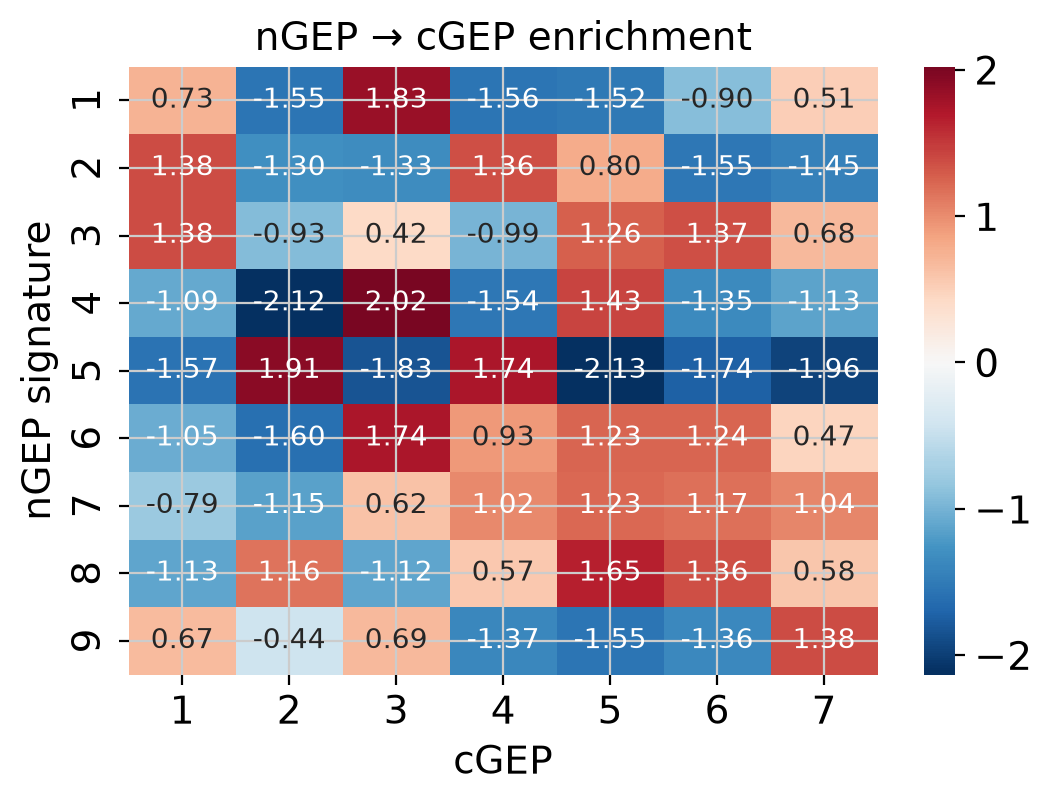

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))

sns.heatmap(
    n_to_c,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
)

plt.xlabel("cGEP")
plt.ylabel("nGEP signature")
plt.title("nGEP → cGEP enrichment")

plt.show()

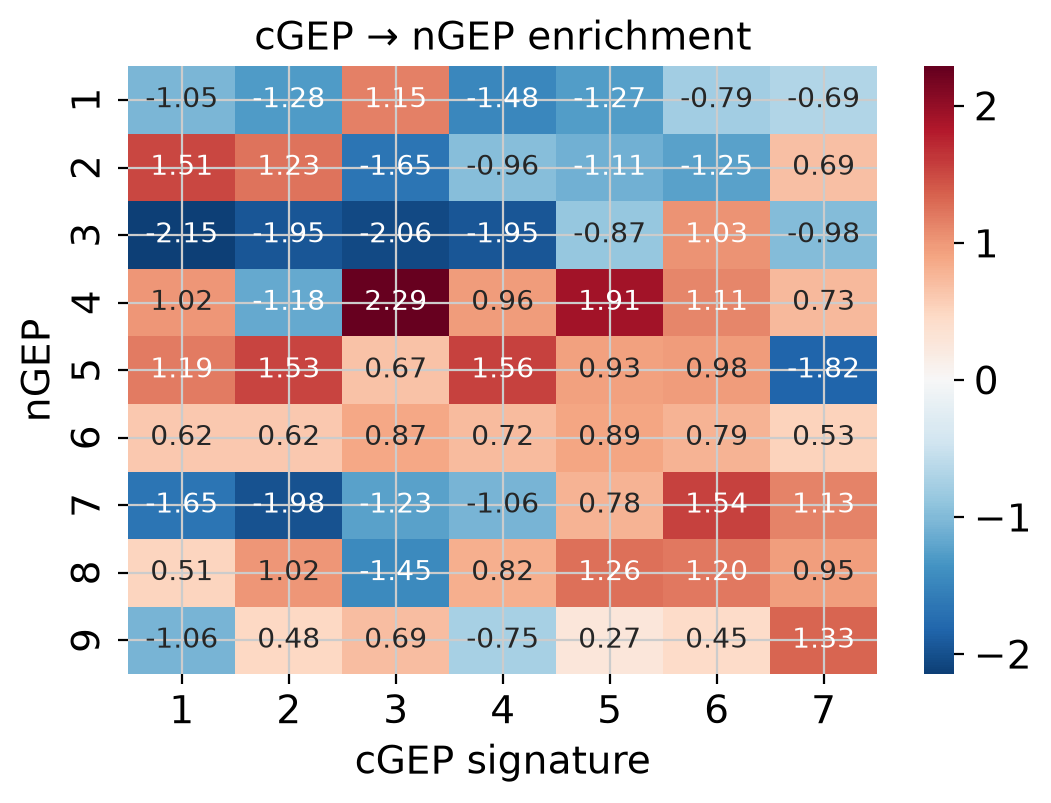

In [24]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    c_to_n_T,
    cmap="RdBu_r",
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}, 
)

plt.xlabel("cGEP signature")
plt.ylabel("nGEP")
plt.title("cGEP → nGEP enrichment")

plt.show()

### top 30, 50, 100

In [25]:
results = {}

for k in [30, 50, 100]:

    n_sig = make_signatures(n, top_k=k)
    c_sig = make_signatures(c, top_k=k)

    nc = enrichment_matrix(
        c,
        n_sig,
        permutation_num=500
    )

    cn = enrichment_matrix(
        n,
        c_sig,
        permutation_num=500
    ).T

    results[k] = {
        "n_to_c": nc,
        "c_to_n": cn,
    }

In [ ]:
results[30]["n_to_c"]
results[50]["n_to_c"]
results[100]["n_to_c"]

## Cross-dataset validation (cell-level)

In [26]:
def make_cross_dataset_signatures(
    source_score,
    target_adata,
    programs=None,
    top_k=50,
):
    """
    source_score:
        programs × genes dataframe

    target_adata:
        AnnData onto which signatures will be projected

    programs:
        programs to use; None = all

    Returns
    -------
    dict:
        {program: [genes present in target_adata]}
    """

    if programs is None:
        programs = source_score.index

    signatures = {}

    for program in programs:

        ranked_genes = (
            source_score
            .loc[program]
            .sort_values(ascending=False)
            .index
        )

        genes = [
            g for g in ranked_genes
            if g in target_adata.var_names
        ][:top_k]

        signatures[str(program)] = genes

    return signatures

In [27]:
from scipy.stats import spearmanr
def signature_usage_correlation(
    adata,
    projected_cols,
    usage_cols,
):
    rho = pd.DataFrame(
        index=projected_cols,
        columns=usage_cols,
        dtype=float,
    )

    pval = rho.copy()

    for x in projected_cols:
        for y in usage_cols:

            valid = (
                adata.obs[x].notna() &
                adata.obs[y].notna()
            )

            r, p = spearmanr(
                adata.obs.loc[valid, x],
                adata.obs.loc[valid, y],
            )

            rho.loc[x, y] = r
            pval.loc[x, y] = p

    return rho, pval

In [28]:
from statsmodels.stats.multitest import multipletests

# FDR correction across the entire matrix
p_flat = p_n2c.values.flatten()

_, q_flat, _, _ = multipletests(
    p_flat,
    method="fdr_bh"
)

q_n2c = pd.DataFrame(
    q_flat.reshape(p_n2c.shape),
    index=p_n2c.index,
    columns=p_n2c.columns,
)

NameError: name 'p_n2c' is not defined

In [55]:
def significance_stars(q):
    if q < 0.001:
        return "***"
    elif q < 0.01:
        return "**"
    elif q < 0.05:
        return "*"
    else:
        return ""

### n to c

In [29]:
n_signatures = make_cross_dataset_signatures(
    source_score=n_spectra,
    target_adata=cdata,
    programs=[1, 2, 4, 5],
    top_k=50,
)

for gep, genes in n_signatures.items():
    print(f"nGEP{gep}: {len(genes)} genes")
    print(genes[:10])

nGEP1: 50 genes
['HS3ST4', 'FRMD4A', 'SORL1', 'KCNQ3', 'CPED1', 'ANKRD44', 'ITPR2', 'ARHGAP24', 'P2RY12', 'CYFIP1']
nGEP2: 50 genes
['FKBP5', 'CSGALNACT1', 'ZBTB16', 'ELMO1', 'CTTNBP2', 'NHSL1', 'PRKCH', 'SPTLC2', 'PDE3B', 'KLF7']
nGEP4: 50 genes
['B2M', 'C1QB', 'CD74', 'APOE', 'FTL', 'HLA-B', 'HLA-DRA', 'C1QA', 'C1QC', 'FTH1']
nGEP5: 50 genes
['CCL4', 'CCL3', 'FLT1', 'CD83', 'CCL2', 'CCL4L2', 'PLAUR', 'IL1B', 'SPRED1', 'SPP1']


In [30]:
for gep, genes in n_signatures.items():

    sc.tl.score_genes(
        cdata,
        gene_list=genes,
        score_name=f"projected_nGEP{gep}",
        use_raw=False,
        random_state=42,
    )

computing score 'projected_nGEP1'
    finished: added
    'projected_nGEP1', score of gene set (adata.obs).
    700 total control genes are used. (0:02:47)
computing score 'projected_nGEP2'
    finished: added
    'projected_nGEP2', score of gene set (adata.obs).
    798 total control genes are used. (0:00:40)
computing score 'projected_nGEP4'
    finished: added
    'projected_nGEP4', score of gene set (adata.obs).
    799 total control genes are used. (0:00:42)
computing score 'projected_nGEP5'
    finished: added
    'projected_nGEP5', score of gene set (adata.obs).
    649 total control genes are used. (0:00:37)


In [31]:
c_usage = c_usage.loc[cdata.obs_names]

In [32]:
c_usage.columns = [
    f"cGEP{x}" if not str(x).startswith("cGEP") else str(x)
    for x in c_usage.columns
]

In [33]:
for col in c_usage.columns:
    cdata.obs[col] = c_usage[col].values

In [34]:
cdata.obs[
    ["projected_nGEP1", "projected_nGEP2"] +
    list(c_usage.columns)
].head()

,projected_nGEP1,projected_nGEP2,cGEP1,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7
AAACCCAAGGCTAACG-1-GSM6049632,0.601914,-0.059241,0.873044,0.000000,0.239724,0.001417,0.000000,0.033650,0.000000
AAACCCAAGGTCGAGT-1-GSM6049632,0.385782,-0.205196,0.821366,0.000000,0.207274,0.000000,0.000000,0.007498,0.000000
AAACCCAAGTCTTGGT-1-GSM6049632,0.541394,-0.013207,0.802997,0.000000,0.252668,0.000000,0.023195,0.022867,0.009405
AAACCCACAACCCGCA-1-GSM6049632,0.206133,-0.065483,0.501872,0.355494,0.000000,0.007651,0.000000,0.001227,0.086644
AAACCCACAAGTACCT-1-GSM6049632,0.498770,-0.146443,0.497853,0.040563,0.342411,0.024769,0.021122,0.002992,0.002589


In [35]:
projected_n = [
    "projected_nGEP1",
    "projected_nGEP2",
    "projected_nGEP4",
    "projected_nGEP5",
]

native_c = list(c_usage.columns)

rho_n2c, p_n2c = signature_usage_correlation(
    cdata,
    projected_cols=projected_n,
    usage_cols=native_c,
)

rho_n2c

,cGEP1,cGEP2,cGEP3,cGEP4,cGEP5,cGEP6,cGEP7
projected_nGEP1,0.446638,-0.316073,0.493102,-0.442729,-0.241812,-0.133641,0.114482
projected_nGEP2,0.382971,-0.106356,-0.243390,-0.028347,0.178917,-0.092146,0.018711
projected_nGEP4,-0.168696,-0.215232,0.565002,-0.161759,0.261727,0.034120,-0.061437
projected_nGEP5,-0.514676,0.557434,-0.443340,0.702939,-0.115623,-0.057609,-0.145636


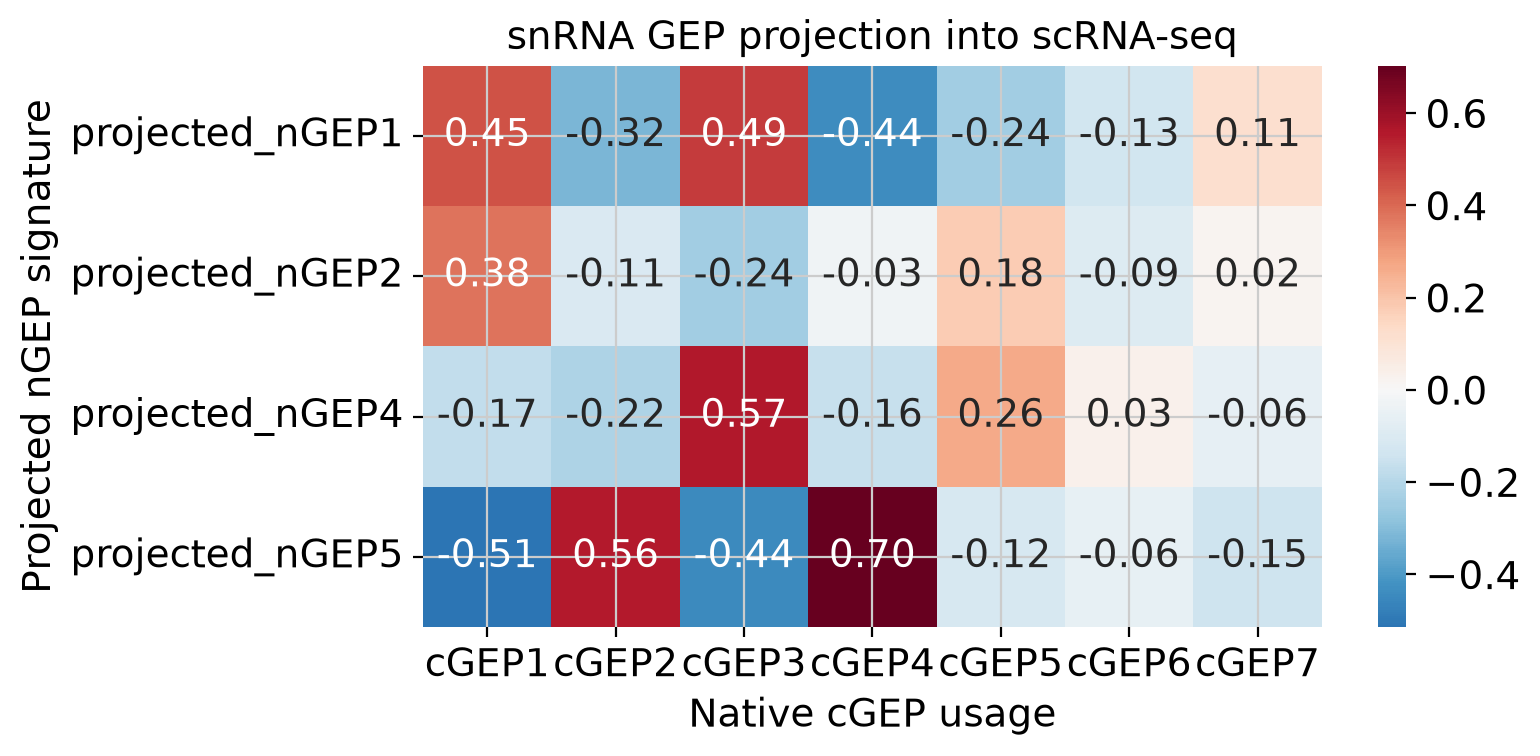

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))

sns.heatmap(
    rho_n2c,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)

plt.xlabel("Native cGEP usage")
plt.ylabel("Projected nGEP signature")
plt.title("snRNA GEP projection into scRNA-seq")

plt.tight_layout()
plt.show()

In [56]:
annot = rho_n2c.copy().astype(object)

for i in rho_n2c.index:
    for j in rho_n2c.columns:
        annot.loc[i, j] = (
            f"{rho_n2c.loc[i, j]:.2f}"
            f"{significance_stars(q_n2c.loc[i, j])}"
        )

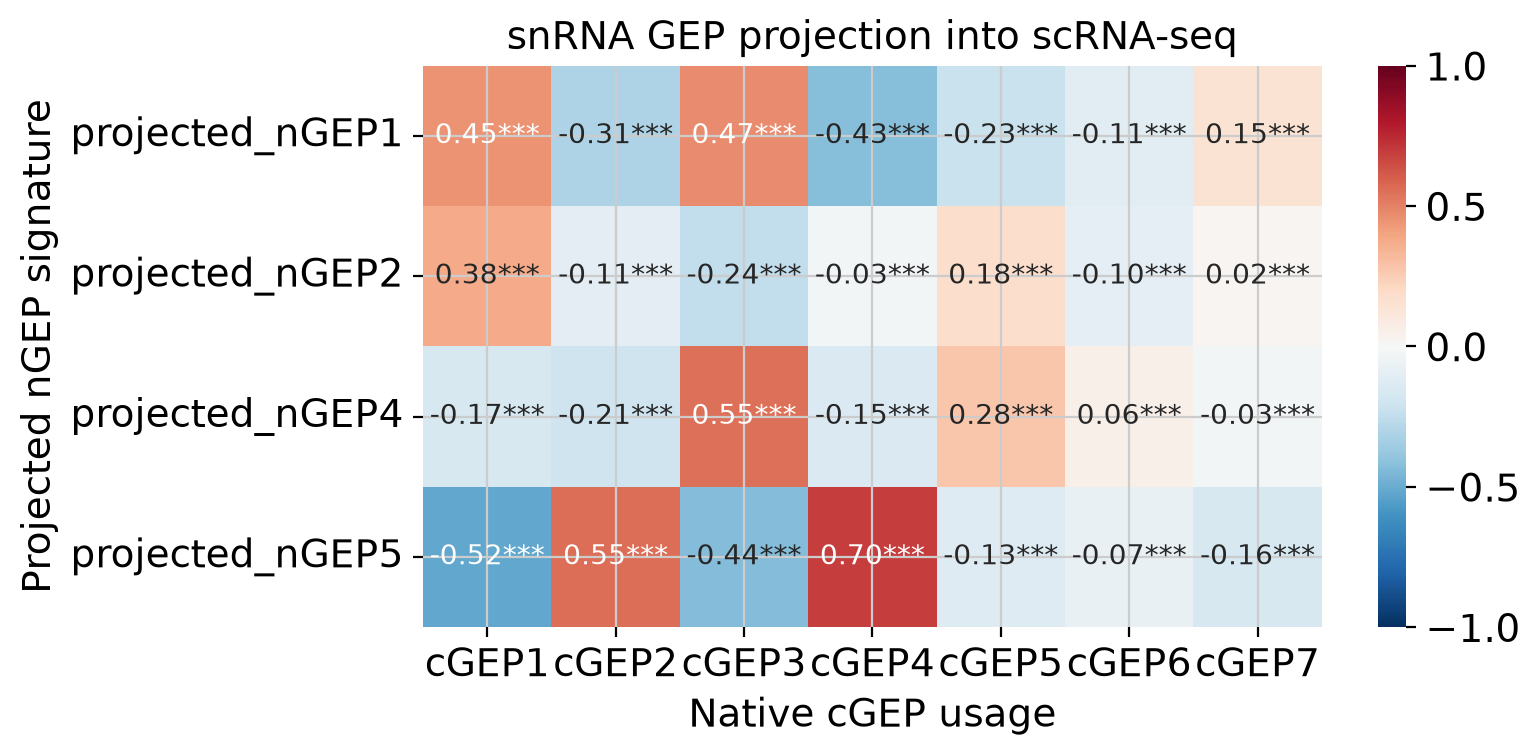

In [58]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))

sns.heatmap(
    rho_n2c,
    annot=annot,
    fmt="",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    annot_kws={"size": 10}, 
)

plt.xlabel("Native cGEP usage")
plt.ylabel("Projected nGEP signature")
plt.title("snRNA GEP projection into scRNA-seq")

plt.tight_layout()
plt.show()

### c to n

In [37]:
c_signatures = make_cross_dataset_signatures(
    source_score=c_spectra,
    target_adata=ndata,
    programs=c_spectra.index,
    top_k=50,
)

In [38]:
for gep, genes in c_signatures.items():

    sc.tl.score_genes(
        ndata,
        gene_list=genes,
        score_name=f"projected_cGEP{gep}",
        use_raw=False,
        random_state=42,
    )

computing score 'projected_cGEP1'
    finished: added
    'projected_cGEP1', score of gene set (adata.obs).
    1047 total control genes are used. (0:00:02)
computing score 'projected_cGEP2'
    finished: added
    'projected_cGEP2', score of gene set (adata.obs).
    996 total control genes are used. (0:00:02)
computing score 'projected_cGEP3'
    finished: added
    'projected_cGEP3', score of gene set (adata.obs).
    995 total control genes are used. (0:00:02)
computing score 'projected_cGEP4'
    finished: added
    'projected_cGEP4', score of gene set (adata.obs).
    999 total control genes are used. (0:00:02)
computing score 'projected_cGEP5'
    finished: added
    'projected_cGEP5', score of gene set (adata.obs).
    948 total control genes are used. (0:00:02)
computing score 'projected_cGEP6'
    finished: added
    'projected_cGEP6', score of gene set (adata.obs).
    997 total control genes are used. (0:00:02)
computing score 'projected_cGEP7'
    finished: added
    'proj

In [39]:
n_usage = n_usage.loc[ndata.obs_names]

n_usage.columns = [
    f"nGEP{x}" if not str(x).startswith("nGEP") else str(x)
    for x in n_usage.columns
]

for col in n_usage.columns:
    ndata.obs[col] = n_usage[col].values

In [40]:
projected_c = [
    f"projected_cGEP{x}"
    for x in c_spectra.index
]

native_n = [
    "nGEP1",
    "nGEP2",
    "nGEP4",
    "nGEP5",
]

rho_c2n, p_c2n = signature_usage_correlation(
    ndata,
    projected_cols=projected_c,
    usage_cols=native_n,
)

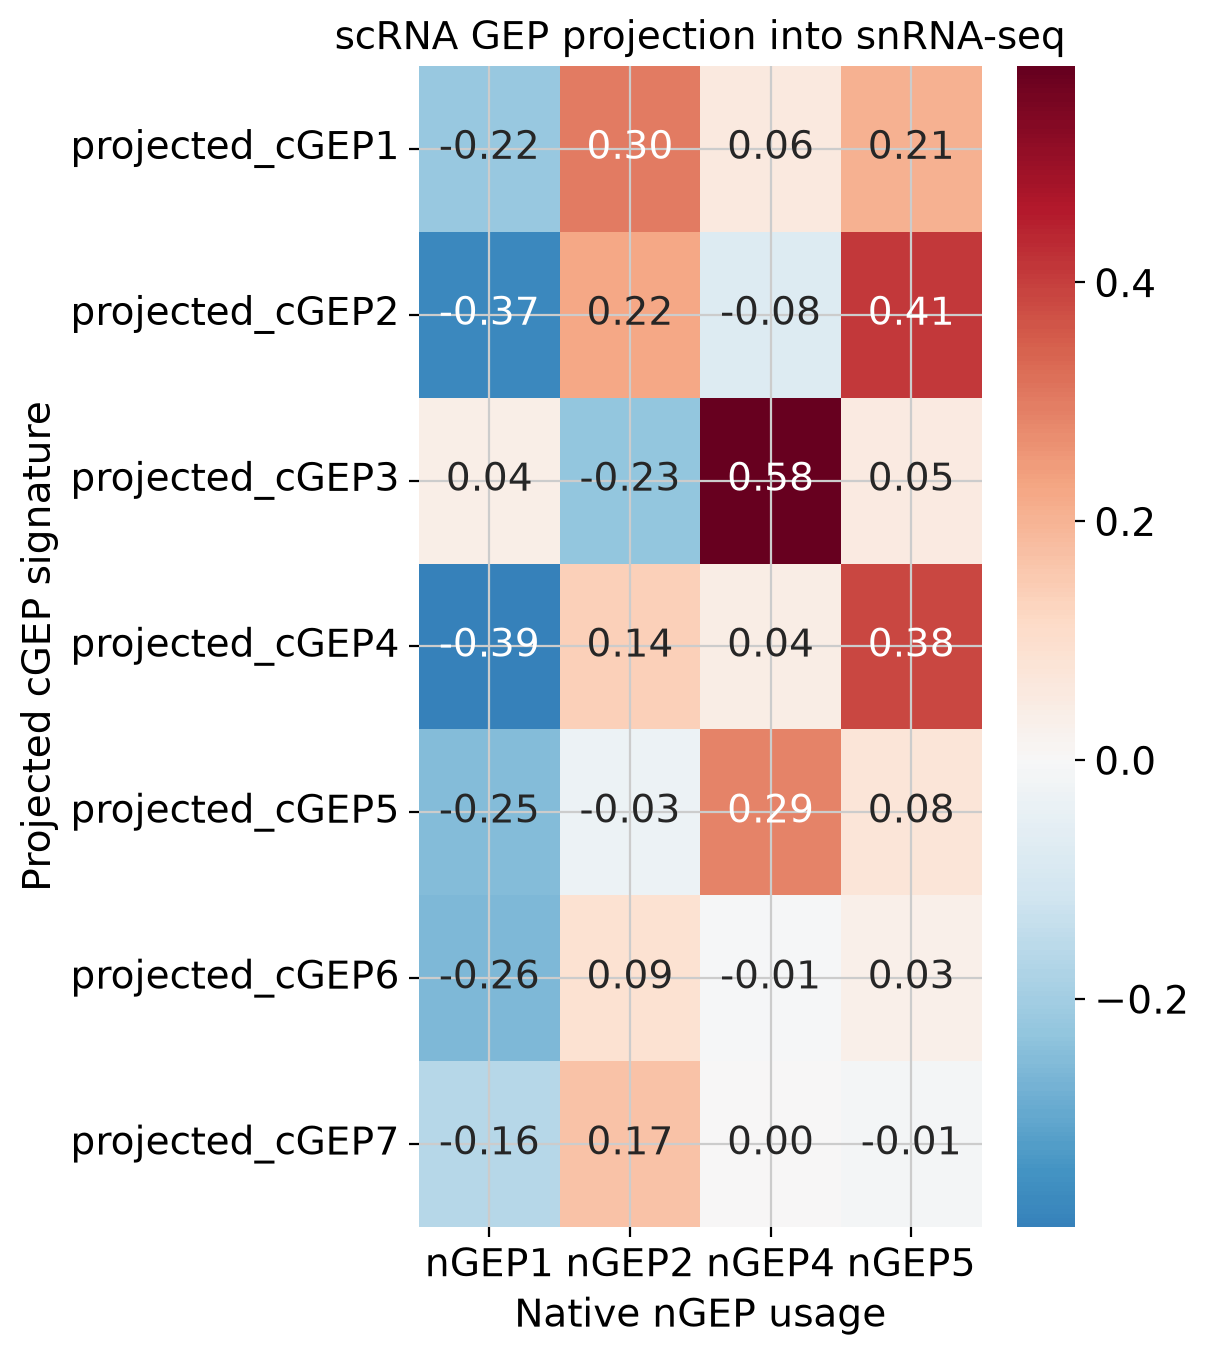

In [41]:
plt.figure(figsize=(6, 7))

sns.heatmap(
    rho_c2n,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
)

plt.xlabel("Native nGEP usage")
plt.ylabel("Projected cGEP signature")
plt.title("scRNA GEP projection into snRNA-seq")

plt.tight_layout()
plt.show()